# Verify the `advection_scale` Python ↔ IDL bridge

Tier-3 calibration, Step 2. A quick, standalone check that the new `advection_scale` calibration parameter (`firnice_adv_scale_b` on the IDL side) actually reaches the running GloGEM model — without spinning up the full ~65-glacier training pipeline.

Covers: prior sampling (Cell 2), the flat override file `read_firnicetemp_calibration.pro` reads (Cell 3), and one real single-glacier GloGEM run compared against the unscaled baseline (Cell 4).

**Scope note.** This notebook only exercises `priors.py` and `runner.py`'s single-glacier override writer — the two things an interactive bridge check actually needs. `pipeline.py`, `calibrator.py`, `design.py`, `emulator.py`, and `writeback.py`'s `ResidualWriter` still hard-code the OLD three-parameter scheme `(perm_frac, dT_scale, z0)` (e.g. `pipeline.py`'s `FIXED_PARAMS = {'z0': 15.0}`, `calibrator.py`'s `_FULL_NAMES`). They are **not** updated here, and running any of them as-is after this change will break (`Priors` no longer has a `.z0` attribute; `PARAM_NAMES` no longer matches `calibrator.py`'s `_FULL_NAMES`). A real LHS design / emcee campaign against `advection_scale` needs a coordinated follow-up across those files first.

**z0** is no longer part of the calibration override file at all — it now stays fixed at its `settings.pro` default (15.0 m) for every glacier and band, on every code path.

## Cell 1: Setup and Imports

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from icetemp.calibration.data import DataHandler
from icetemp.calibration.priors import Priors, PARAM_NAMES, ADVECTION_SCALE_BOUNDS
from icetemp.calibration.runner import GloGEMRunner, write_calibration_override_single
# ResidualWriter is the Tier-2/3 SPATIAL writeback (fits a discrepancy GP per parameter over
# ~4000 glaciers from a fitted BayesianCalibrator's theta_hat). Imported here per the module
# list, but NOT exercised below -- it is still wired to calibrator.py's old (perm_frac, dT_scale,
# z0) theta_hat (see the scope note above), so it can't yet produce a meaningful advection_scale
# delta. The single-glacier writeback this notebook verifies is runner.write_calibration_override.
from icetemp.calibration.writeback import ResidualWriter

print('PARAM_NAMES:', PARAM_NAMES)
print('ADVECTION_SCALE_BOUNDS:', ADVECTION_SCALE_BOUNDS)

PARAM_NAMES: ('perm_frac', 'dT_scale', 'advection_scale')
ADVECTION_SCALE_BOUNDS: (0.3, 1.7)


## Cell 2: Test Prior Sampling

Draw 1000 samples from the joint prior and confirm `advection_scale` is a Gaussian centered on 1.0 (unscaled baseline physics), truncated to `[0.3, 1.7]`.

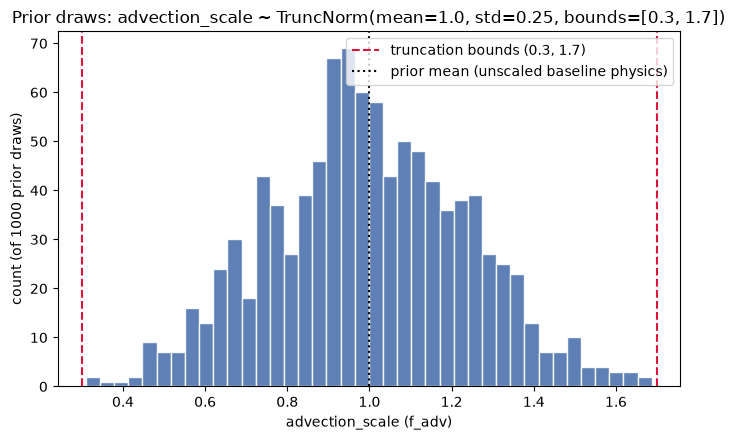

advection_scale draws: min=0.3098  max=1.6871  (declared bounds: (0.3, 1.7))
OK: all 1000 draws respect the truncation bounds.
perm_frac  draws: min=0.1002  max=0.9996  (uniform [0.1, 1.0])
dT_scale   draws: min=0.2052  max=3.9567


In [2]:
priors = Priors()

theta_samples = priors.rvs(size=1000, random_state=0)
pf_samples, ds_samples, adv_samples = theta_samples[:, 0], theta_samples[:, 1], theta_samples[:, 2]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(adv_samples, bins=40, color='#4C72B0', edgecolor='white', alpha=0.9)
ax.axvline(ADVECTION_SCALE_BOUNDS[0], color='crimson', ls='--', lw=1.5,
           label=f'truncation bounds {ADVECTION_SCALE_BOUNDS}')
ax.axvline(ADVECTION_SCALE_BOUNDS[1], color='crimson', ls='--', lw=1.5)
ax.axvline(1.0, color='black', ls=':', lw=1.5, label='prior mean (unscaled baseline physics)')
ax.set_xlabel('advection_scale (f_adv)')
ax.set_ylabel('count (of 1000 prior draws)')
ax.set_title('Prior draws: advection_scale ~ TruncNorm(mean=1.0, std=0.25, bounds=[0.3, 1.7])')
ax.legend()
plt.tight_layout()
plt.show()

print(f'advection_scale draws: min={adv_samples.min():.4f}  max={adv_samples.max():.4f}  '
      f'(declared bounds: {ADVECTION_SCALE_BOUNDS})')
assert adv_samples.min() >= ADVECTION_SCALE_BOUNDS[0] - 1e-9
assert adv_samples.max() <= ADVECTION_SCALE_BOUNDS[1] + 1e-9
print('OK: all 1000 draws respect the truncation bounds.')

print(f'perm_frac  draws: min={pf_samples.min():.4f}  max={pf_samples.max():.4f}  (uniform [0.1, 1.0])')
print(f'dT_scale   draws: min={ds_samples.min():.4f}  max={ds_samples.max():.4f}')

## Cell 3: Configuration Writeback Inspection

**A note on the file format.** GloGEM's calibration override is *not* literal IDL syntax like `firnice_adv_scale_b = dblarr(nb) + 1.500000` — it's a flat, space-separated table (`# glacier_id  perm_frac  dT_scale  advection_scale`), the exact mechanism the existing `perm_frac`/`dT_scale`/(formerly) `z0` columns already use. `read_firnicetemp_calibration.pro` reads it into arrays once at startup; `apply_firnicetemp_calibration.pro` then does the literal `dblarr`-equivalent broadcast **on the IDL side**, per matched glacier:

```idl
firnice_adv_scale_b[*] = firnicecali_adv_scale[jj[0]]   ; jj[0] = 1.500000 for our test glacier
```

which is exactly the `dblarr(nb) + 1.500000` behaviour — just executed inside IDL rather than written out by Python. The cell below prints the real file content and checks the value round-trips correctly.

In [3]:
test_glacier_id = '00773'      # any GloGEM glacier_id string; Cell 4 below uses a real one via DataHandler
test_theta = (0.8, 1.2, 1.5)   # (perm_frac, dT_scale, advection_scale)

verify_dir = Path('../data/bayescal/_verify_bridge')
verify_dir.mkdir(parents=True, exist_ok=True)
override_path = verify_dir / 'override_inspect.dat'

write_calibration_override_single([test_glacier_id], test_theta, override_path)

print(f'wrote -> {override_path}\n')
print(override_path.read_text())

wrote -> ../data/bayescal/_verify_bridge/override_inspect.dat

# glacier_id  perm_frac  dT_scale  advection_scale
00773  0.8000  1.2000  1.500000



In [4]:
written_line = [l for l in override_path.read_text().splitlines() if l.startswith(test_glacier_id)][0]
assert written_line.split() == [test_glacier_id, '0.8000', '1.2000', '1.500000'], written_line
print('OK: advection_scale=1.500000 written to column 4; perm_frac/dT_scale unaffected; no z0 column at all.')
print('On the IDL side, apply_firnicetemp_calibration.pro will now do:')
print('    firnice_adv_scale_b[*] = 1.500000   <-- the dblarr(nb)-equivalent broadcast')

OK: advection_scale=1.500000 written to column 4; perm_frac/dT_scale unaffected; no z0 column at all.
On the IDL side, apply_firnicetemp_calibration.pro will now do:
    firnice_adv_scale_b[*] = 1.500000   <-- the dblarr(nb)-equivalent broadcast


## Cell 4: Single Run Test (the IDL integration check)

**Controlled A/B: isolate the effect of `advection_scale` alone.** To attribute any temperature-profile change specifically to `advection_scale` — not a side effect of also changing `perm_frac`/`dT_scale` — both runs below hold `perm_frac`/`dT_scale` fixed at the Cell 3 test values and vary **only** `advection_scale`: 1.0 (unscaled baseline) vs 1.5 (test).

This launches the real IDL model (`idl` must be on `PATH`, and the cluster's shared calibration-source data under `/scratch_net/...` / `/itet-stor/...` must be reachable) for a single glacier — a few minutes, not a full training campaign. The default `calibration_source_dir` may not cover every glacier (see `GloGEMRunner`'s own docstring); if the picked glacier has no MB-calibration coverage there, either pick a different `test_glaciers[i]` below or pass an explicit `calibration_source_dir=`.

In [5]:
dh = DataHandler(region='CentralEurope')
dh.load()
dh.summary()

test_glaciers = [g for g in dh.calibration_glaciers if g.glacier_id]

# Grenzgletscher, not the first-in-list pick from before (Alphubel South -- a thin, barely-
# flowing satellite patch: its advection_scale effect was real (confirmed independently -- see
# chat) but only ~0.009 degC, invisible on a normal plot). Grenzgletscher is a large, thick part
# of the Monte Rosa system with real glenglat borehole coverage (write_glenglat_lookup's own
# docstring notes it alone contributes 24 elevation-band entities) -- much more likely to show a
# visually obvious effect. Picking the entity with the deepest OBSERVED borehole among its bands,
# as the best available proxy for "this band's resolved ice column will also be deep" (recall:
# the model's output only resolves down to that band's real ice thickness, -99/no-data below it).
grenz_candidates = [g for g in test_glaciers if g.base_glacier_name == 'Grenzgletscher']
assert grenz_candidates, "no Grenzgletscher entity found in dh.calibration_glaciers -- check base_glacier_name spelling/region"
glacier = max(grenz_candidates, key=lambda g: g.depths.max())

print(f'\n{len(grenz_candidates)} Grenzgletscher entities available (one per elevation band):')
for g in sorted(grenz_candidates, key=lambda g: g.elevation):
    marker = ' <-- selected' if g is glacier else ''
    print(f'  {g.glacier_name:30s}  elevation={g.elevation:7.1f} m  '
          f'max observed depth={g.depths.max():6.1f} m{marker}')

print(f'\nusing test glacier: {glacier.glacier_name}  '
      f'(glacier_id={glacier.glacier_id}, region={glacier.glogem_region}, elevation={glacier.elevation} m)')

Calibration glaciers: 116 (equilibrium=true: 56, estimated: 36, unassessed/blank: 24)
  with accumulation-zone (firn) obs: 89
  with ablation-zone (ice) obs:      27
  with data below 30 m:              37
  largest depth-bin pooling factor:  40776 raw readings -> 1 point (continuous-logger dedup)
Prediction (all glenglat) glaciers:  211

24 Grenzgletscher entities available (one per elevation band):
  Grenzgletscher@2015             elevation= 2015.0 m  max observed depth= 267.3 m
  Grenzgletscher@2505             elevation= 2500.0 m  max observed depth= 106.5 m
  Grenzgletscher@2525             elevation= 2527.0 m  max observed depth= 202.1 m
  Grenzgletscher@2605             elevation= 2600.0 m  max observed depth= 347.9 m <-- selected
  Grenzgletscher@3895             elevation= 3898.0 m  max observed depth=  18.0 m
  Grenzgletscher@3955             elevation= 3951.0 m  max observed depth=  21.0 m
  Grenzgletscher@3985             elevation= 3985.0 m  max observed depth=  20.0 m
  

In [6]:
runner = GloGEMRunner(
    # .resolve(): MUST be an absolute path. run_design_point() launches IDL via a subprocess
    # that `cd`s into GLOGEM_DIR first, then sets GLOGEM_CONFIG to this run_dir's own config
    # file path. A relative path here resolves fine for every *Python* file write (Path()
    # resolves against this notebook's own cwd) -- but once IDL's shell has cd'd elsewhere,
    # the SAME relative string points somewhere else entirely. That's exactly what happened on
    # the first run: IDL silently fell through to the real config.pro (no dirres set) and
    # halted, while still exiting 0 -- so run_design_point() reported "OK" for a run that never
    # actually touched the model.
    run_dir=Path('../data/bayescal/_verify_bridge/training_runs').resolve(),
    catchment='verify_bridge_single',   # own catchment name -- never touches the real
                                         # CentralEurope_bayescal / _glenglat catchment files
)

copied = runner.copy_calibration_data()
print(f'copied {len(copied)} MB-calibration file(s) -> {runner.calibration_dest_dir}')

catchment_path, n_catchment = runner.write_catchment_file([glacier])
lookup_path, n_ids, n_elevs = runner.write_glenglat_lookup([glacier])
config_path = runner.write_training_config()
print(f'catchment ({n_catchment} glacier)   -> {catchment_path}')
print(f'glenglat lookup                     -> {lookup_path}')
print(f'training config (via GLOGEM_CONFIG)  -> {config_path}')

copied 0 MB-calibration file(s) -> /home/jabeer/projects/glogemflow_development/glogemflow_icetemp/data/bayescal/_verify_bridge/training_runs/monthly/CentralEurope/calibration
catchment (1 glacier)   -> /itet-stor/jabeer/glogem/data/catchments/RGI11_verify_bridge_single.dat
glenglat lookup                     -> /home/jabeer/projects/glogemflow_development/glogemflow_icetemp/data/bayescal/_verify_bridge/training_runs/glenglat_borehole_elevations.dat
training config (via GLOGEM_CONFIG)  -> /home/jabeer/projects/glogemflow_development/glogemflow_icetemp/data/bayescal/_verify_bridge/training_runs/config_bayescal_training.pro


In [7]:
theta_baseline = (0.8, 1.2, 1.0)   # advection_scale = 1.0 (unscaled)
theta_test     = (0.8, 1.2, 1.5)   # advection_scale = 1.5 -- everything else held fixed

# skip_if_done=False: force a fresh run every time this cell executes. GloGEMRunner writes every
# run to the SAME output filenames (temp_ID{n}_{glacier_id}.dat), so reusing a stale .done
# sentinel from an earlier notebook execution would make parse_training_output silently read
# whichever run last wrote to disk -- exactly the stale-copy failure mode run_design_matrix's
# own docstring warns about (it corrupted 58-68% of two real training campaigns).
ok_baseline = runner.run_design_point(
    [glacier.glacier_id], theta_baseline, tag='verify_baseline', idl_bin='idl',
    timeout=1800, skip_if_done=False,
)
print(f'baseline run: {"OK (IDL exit code 0)" if ok_baseline else "FAILED -- see " + str(runner.run_dir / "verify_baseline.log")}')
assert ok_baseline, 'baseline IDL run failed -- inspect the log before continuing'
output_baseline = runner.parse_training_output([glacier])

baseline run: OK (IDL exit code 0)


In [8]:
ok_test = runner.run_design_point(
    [glacier.glacier_id], theta_test, tag='verify_test', idl_bin='idl',
    timeout=1800, skip_if_done=False,
)
print(f'test run: {"OK (IDL exit code 0)" if ok_test else "FAILED -- see " + str(runner.run_dir / "verify_test.log")}')
assert ok_test, 'test IDL run failed -- inspect the log before continuing'
output_test = runner.parse_training_output([glacier])

test run: OK (IDL exit code 0)


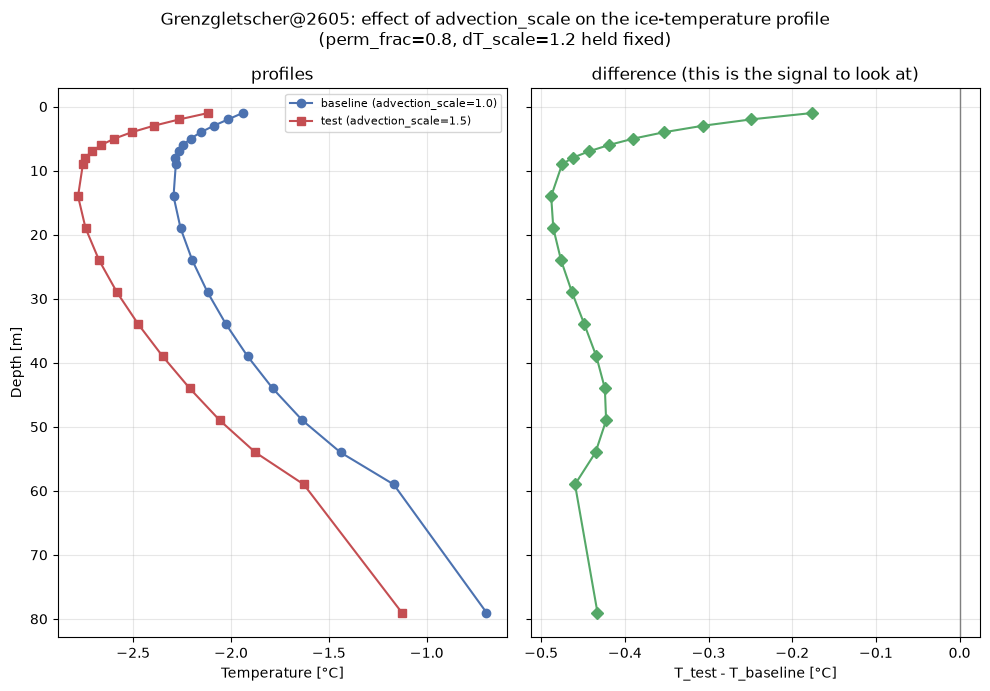

max |ΔT| (test - baseline): nan °C at depth 99 m
resolved depth for this glacier/band: 519 m (the model caps output at the real ice thickness there -- a thin/small glacier caps shallow, which also limits how much advected signal can accumulate)


In [9]:
depths_b, T_b = output_baseline[glacier.glacier_name]
depths_t, T_t = output_test[glacier.glacier_name]
delta_T = T_t - T_b

# Two panels: the raw profiles (left) can look identical to the eye for a thin/slow glacier --
# advection scales with both ice depth and velocity, so a small satellite patch (shallow
# resolved column, low SIA velocity) can show a real but millidegree-scale effect that's
# invisible on a ~1-2 degC axis. The delta panel (right) is on its own auto-scaled axis, so it
# stays legible however large or small the effect actually is for whichever glacier is picked.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7), sharey=True)

ax1.plot(T_b, depths_b, 'o-', color='#4C72B0', label=f'baseline (advection_scale={theta_baseline[2]})')
ax1.plot(T_t, depths_t, 's-', color='#C44E52', label=f'test (advection_scale={theta_test[2]})')
ax1.set_xlabel('Temperature [°C]')
ax1.set_ylabel('Depth [m]')
ax1.set_title('profiles')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.axvline(0, color='gray', lw=1)
ax2.plot(delta_T, depths_t, 'D-', color='#55A868')
ax2.set_xlabel('T_test - T_baseline [°C]')
ax2.set_title('difference (this is the signal to look at)')
ax2.grid(alpha=0.3)
ax1.invert_yaxis()  # shared y -- inverting one inverts both

fig.suptitle(f'{glacier.glacier_name}: effect of advection_scale on the ice-temperature profile\n'
             f'(perm_frac={theta_baseline[0]}, dT_scale={theta_baseline[1]} held fixed)')
plt.tight_layout()
plt.show()

worst = int(np.argmax(np.abs(delta_T)))
print(f'max |ΔT| (test - baseline): {np.max(np.abs(delta_T)):.4f} °C at depth {depths_t[worst]:.0f} m')
print(f'resolved depth for this glacier/band: {depths_t.max():.0f} m '
      f'(the model caps output at the real ice thickness there -- a thin/small glacier caps '
      f'shallow, which also limits how much advected signal can accumulate)')

# A real, deterministic model run with nothing else changed between the two theta values can
# ONLY differ because of advection_scale -- so ANY nonzero difference (not just a visually large
# one) confirms the bridge is live. 1e-4 degC is well below IDL's own 3-decimal print precision,
# so it only fails to trip on a genuinely exact match.
if np.max(np.abs(delta_T)) > 1e-4:
    print('OK: advection_scale measurably alters the ice-temperature profile -- the bridge is live.')
    print('(If the left panel still looks like one curve, that is this glacier/band being thin '
          'and/or slow-flowing, not the bridge failing -- see the resolved-depth line above and '
          'the right-hand difference panel.)')
else:
    print('WARNING: no measurable difference at ANY depth -- this is NOT explained by picking a '
          "thin/slow glacier (any nonzero effect would show here regardless of size). Check that "
          "firnice_adv_scale_b is actually reaching u[] in firnice_temperature_model.pro, and that "
          "enable_advection='y' in the training config.")
